# Advanced Features in Complexplorer

This notebook explores the advanced capabilities of complexplorer, including:

1. All colormap types and their uses
2. High-performance 3D visualization with PyVista
3. Riemann sphere projections
4. Domain composition and custom domains
5. STL export for 3D printing
6. Performance optimization techniques

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Core imports - simplified!
import complexplorer as cp

# STL export (keeping separate as it's a specific submodule)
from complexplorer.export.stl import OrnamentGenerator, create_ornament

print("✓ All imports successful")

import pyvista as pv
# Render PyVista 3D inline as static images; use examples/scripts/ for interactive views.
pv.set_jupyter_backend('static')

✓ All imports successful


## 1. Comprehensive Colormap Guide

Complexplorer offers various colormaps, each revealing different aspects of complex functions.

In [2]:
# Test function with interesting features
def f(z):
    return (z**3 - 1) / (z**3 + 1)

domain = cp.Rectangle(3, 3)

### Phase Portraits

In [3]:
# Different phase portrait configurations
phase_configs = [
    ("Basic Phase", cp.Phase()),
    ("Phase Enhanced\n(8 sectors)", cp.Phase(phase_sectors=8)),
    ("Modulus Enhanced\n(r_step=0.4)", cp.Phase(r_linear_step=0.4, v_base=0.5)),
    ("Auto-scaled\n(phase_sectors=6)", cp.Phase(phase_sectors=6, auto_scale_r=True, v_base=0.4)),
    ("Logarithmic\n(base=2)", cp.Phase(phase_sectors=6, r_log_base=2.0, v_base=0.5)),
    ("Fine Detail\n(phase_sectors=12)", cp.Phase(phase_sectors=12, auto_scale_r=True, scale_radius=0.5, v_base=0.3))
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (title, cmap) in zip(axes, phase_configs):
    cp.plot(domain, func=f, cmap=cmap, ax=ax, resolution=400)
    ax.set_title(title)

plt.suptitle(r"Phase Portrait Variations: $f(z) = \frac{z^3 - 1}{z^3 + 1}$", fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\igork\AppData\Local\Temp\ipykernel_14028\450906519.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Chessboard Patterns

In [4]:
# Chessboard patterns show how functions transform grids
chessboard_configs = [
    ("Cartesian\n(spacing=0.25)", cp.Chessboard(spacing=0.25)),
    ("Cartesian\n(spacing=0.5)", cp.Chessboard(spacing=0.5)),
    ("Polar Linear\n(phase_sectors=8, r=0.25)", cp.PolarChessboard(phase_sectors=8, spacing=0.25)),
    ("Polar Log\n(phase_sectors=6, base=e)", cp.PolarChessboard(phase_sectors=6, r_log=np.e)),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, (title, cmap) in zip(axes, chessboard_configs):
    cp.plot(domain, f, cmap=cmap, ax=ax, resolution=500)
    ax.set_title(title)

plt.suptitle("Chessboard Patterns", fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\igork\AppData\Local\Temp\ipykernel_14028\261182890.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Logarithmic Rings

In [5]:
# Function with interesting magnitude behavior
g = lambda z: np.exp(1/z)

# Domain excluding origin
ann = cp.Annulus(0.1, 2.0)

cp.pair_plot(ann, func=g, cmap=cp.LogRings(log_spacing=0.5), resolution=500)
fig.suptitle(r"Logarithmic Rings: $f(z) = e^{1/z}$", fontsize=14)
plt.show()

C:\Users\igork\AppData\Local\Temp\ipykernel_14028\173586478.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 2. High-Performance 3D with PyVista

PyVista is the sole 3D backend as of 3.0. In notebooks the static backend embeds each plot
as an image; run the scripts in `examples/scripts/` from a terminal for interactive views.

### 3D Landscapes

C:\Repos\complexplorer\complexplorer\plotting\pyvista\plot_3d.py:195: UserWarning: PyVista backend is 'static', but 'trame' is recommended for interactive Jupyter visualizations. Set with: pv.set_jupyter_backend('trame')
  ensure_pyvista_setup()


Opening external window for high-quality 3D visualization...


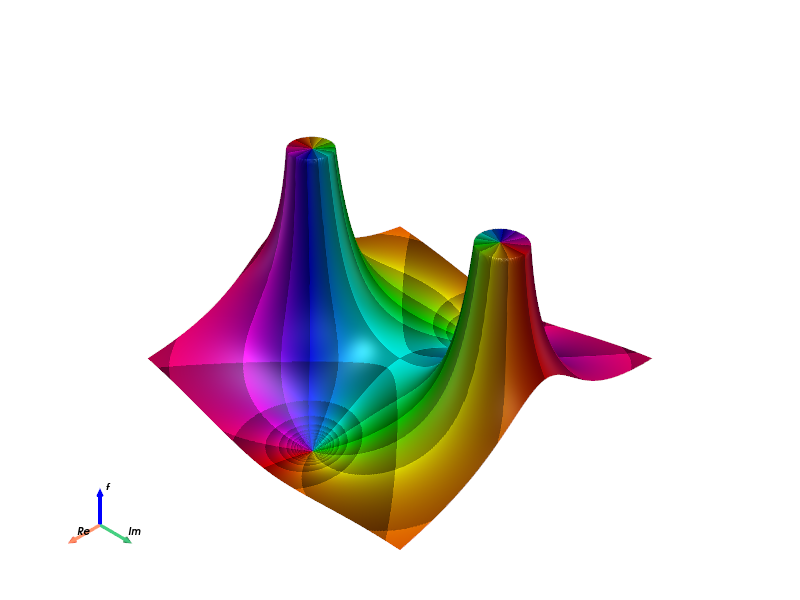

✓ Use mouse to interact: rotate, zoom, pan
✓ Press 'q' to close the window


In [6]:
# Beautiful 3D landscape
print("Opening external window for high-quality 3D visualization...")

cp.plot_landscape_pv(
    domain=cp.Rectangle(3, 3),
    func=lambda z: (z**2 - 1) / (z**2 + 1),
    cmap=cp.Phase(phase_sectors=6, auto_scale_r=True, v_base=0.4),
    resolution=500,
    z_scale=0.4,
    z_max=5.0,  # External window for quality
)

print("✓ Use mouse to interact: rotate, zoom, pan")
print("✓ Press 'q' to close the window")

### Side-by-Side 3D Comparison

Opening side-by-side 3D comparison...


C:\Repos\complexplorer\complexplorer\plotting\pyvista\plot_3d.py:313: UserWarning: PyVista backend is 'static', but 'trame' is recommended for interactive Jupyter visualizations. Set with: pv.set_jupyter_backend('trame')
  ensure_pyvista_setup()


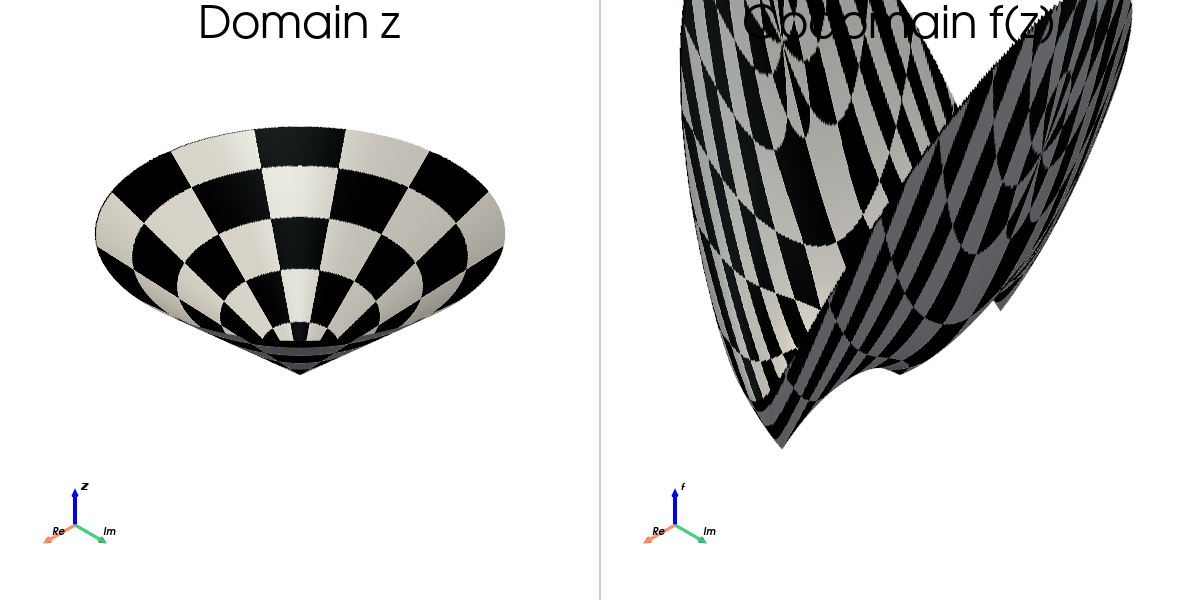

✓ Notice how the function transforms the polar grid


In [7]:
# Compare domain and codomain in 3D
print("Opening side-by-side 3D comparison...")

cp.pair_plot_landscape_pv(
    domain=cp.Disk(1.2),
    func=lambda z: z**3 - z,
    cmap=cp.PolarChessboard(phase_sectors=6, spacing=0.25),
    resolution=500,
    z_max=5
)

print("✓ Notice how the function transforms the polar grid")

## 3. Riemann Sphere Projections

The Riemann sphere allows us to visualize the entire extended complex plane, including the point at infinity.

Opening Riemann sphere visualization...
This function has poles at z = ±i


C:\Repos\complexplorer\complexplorer\plotting\pyvista\riemann.py:127: UserWarning: PyVista backend is 'static', but 'trame' is recommended for interactive Jupyter visualizations. Set with: pv.set_jupyter_backend('trame')
  ensure_pyvista_setup()


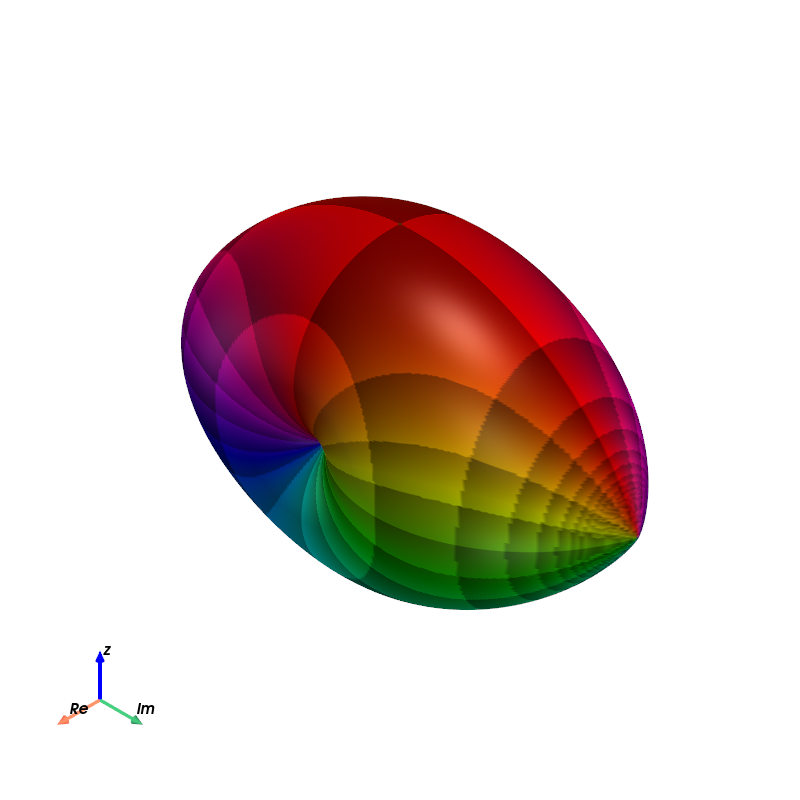


✓ The poles appear as 'pinches' on the sphere
✓ The point at infinity is at the north pole


In [8]:
# Function with a pole - perfect for Riemann sphere
def rational_func(z):
    return (z**2 - 1) / (z**2 + 1)

print("Opening Riemann sphere visualization...")
print("This function has poles at z = ±i")

cp.riemann_pv(
    func=rational_func,
    resolution=500,
    cmap=cp.Phase(phase_sectors=8, auto_scale_r=True, v_base=0.4),
    modulus_mode='arctan',  # Good for functions with poles
    modulus_params={'r_min': 0.3, 'r_max': 0.9}
)

print("\n✓ The poles appear as 'pinches' on the sphere")
print("✓ The point at infinity is at the north pole")

### Different Modulus Scaling Modes

Comparing modulus scaling modes...
(This will open 4 windows sequentially)

Showing constant scaling...


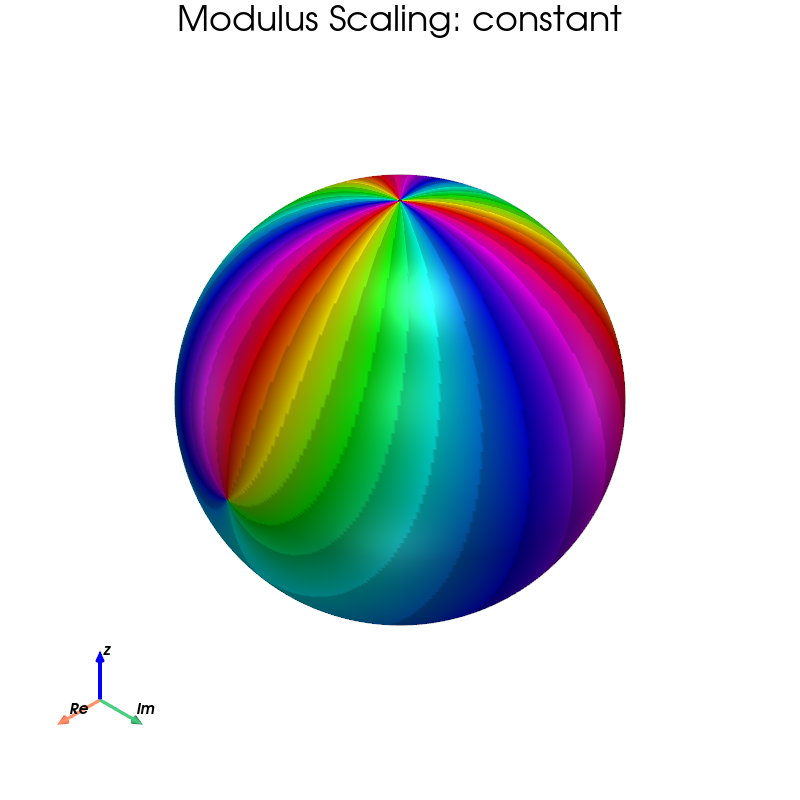

✓ constant scaling shown. Close window to continue.

Showing arctan scaling...


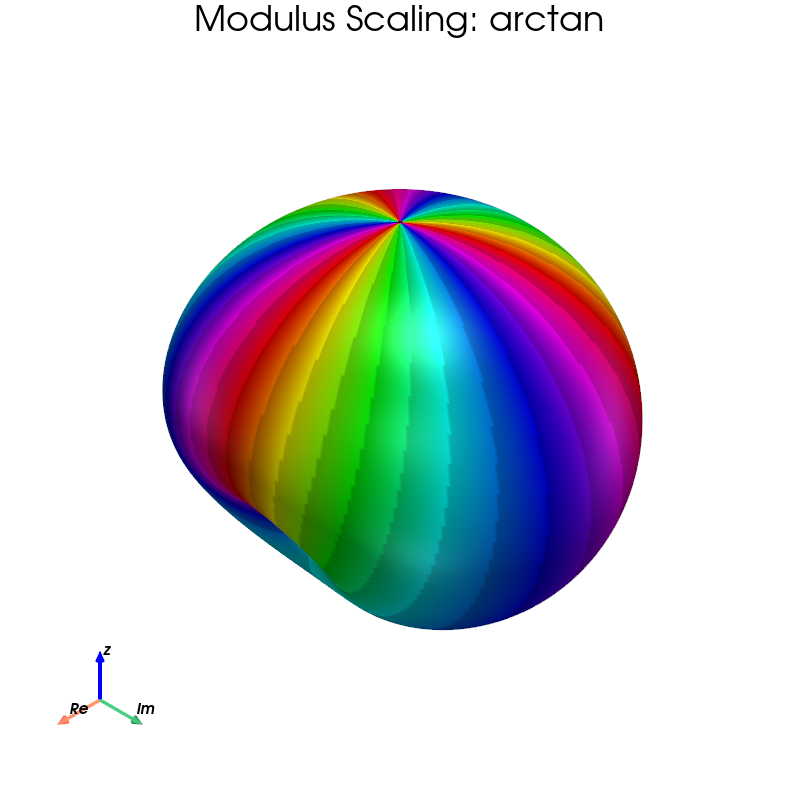

✓ arctan scaling shown. Close window to continue.

Showing logarithmic scaling...


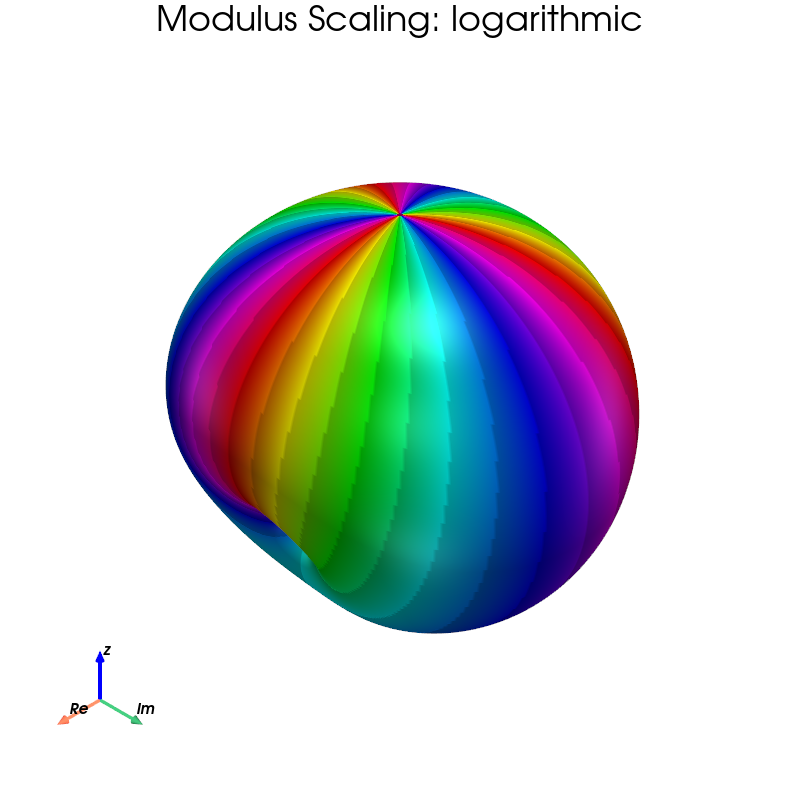

✓ logarithmic scaling shown. Close window to continue.

Showing linear_clamp scaling...


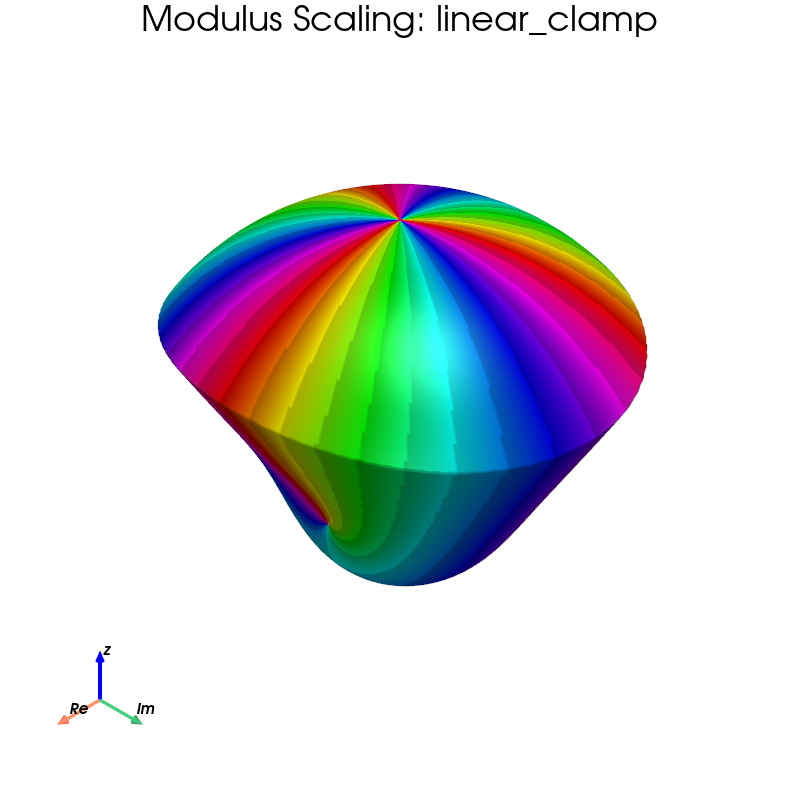

✓ linear_clamp scaling shown. Close window to continue.



In [9]:
# Compare different modulus scaling modes
scaling_modes = ['constant', 'arctan', 'logarithmic', 'linear_clamp']

print("Comparing modulus scaling modes...")
print("(This will open 4 windows sequentially)\n")

for mode in scaling_modes:
    print(f"Showing {mode} scaling...")
    cp.riemann_pv(
        func=lambda z: z**3 - z,
        resolution=500,
        modulus_mode=mode,
        title=f"Modulus Scaling: {mode}"
    )
    print(f"✓ {mode} scaling shown. Close window to continue.\n")

## 3b. Riemann Surfaces of Multivalued Functions

A Riemann **surface** is distinct from the Riemann **sphere**: the sphere shows a
*single-valued* function on the compactified plane, while a surface is the multi-sheeted
cover on which a *multivalued* function (like √z or log z) becomes single-valued.
`riemann_surface_pv` renders these directly.

C:\Repos\complexplorer\complexplorer\plotting\pyvista\riemann_surface.py:80: UserWarning: PyVista backend is 'static', but 'trame' is recommended for interactive Jupyter visualizations. Set with: pv.set_jupyter_backend('trame')
  ensure_pyvista_setup()


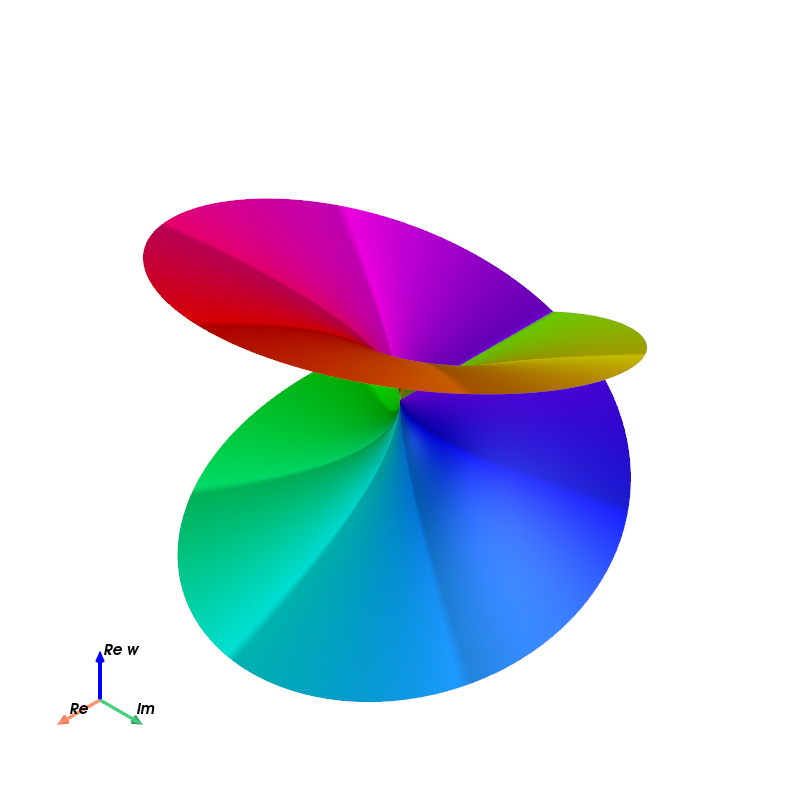

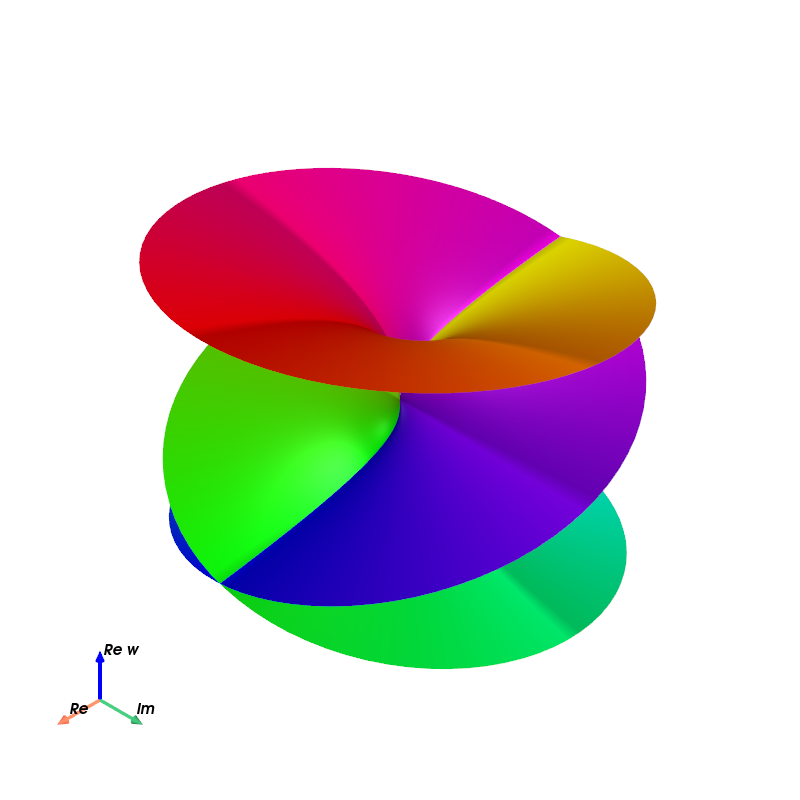

In [10]:
# sqrt(z): a 2-sheeted self-intersecting surface; cube root: 3 sheets
cp.riemann_surface_pv('power', n=2)
cp.riemann_surface_pv('power', n=3)

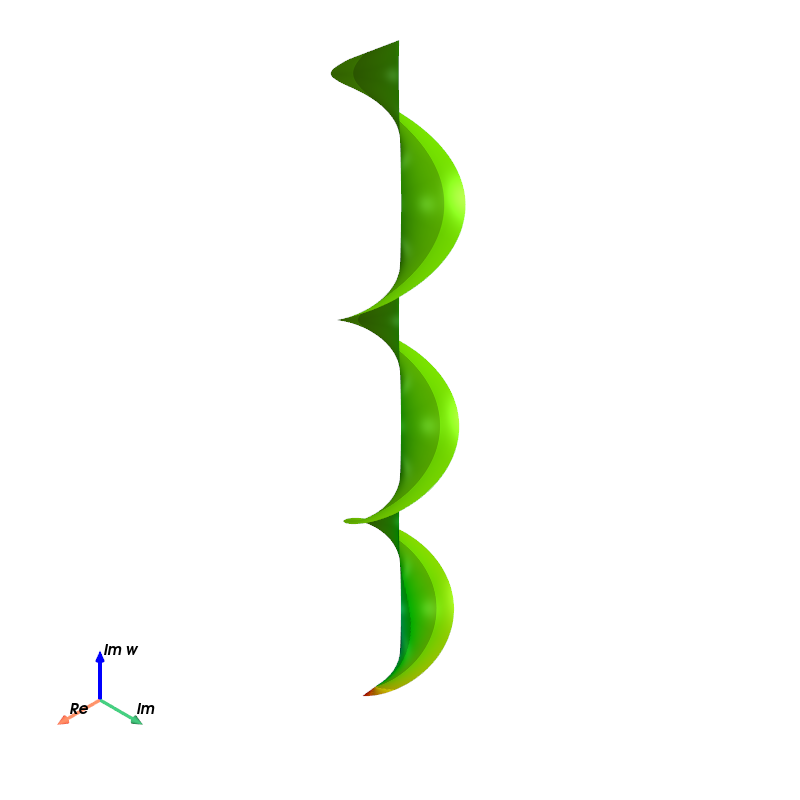

In [11]:
# log(z): an infinite helicoid (shown for a few turns)
cp.riemann_surface_pv('log', turns=3)

## 4. Domain Composition

Create complex domains by combining simple ones.

In [12]:
# Create interesting composite domains
rect = cp.Rectangle(2, 2)
disk1 = cp.Disk(1.5, center=-1-1j)
disk2 = cp.Disk(1.5, center=1+1j)

# Union: combine domains
union_domain = rect | disk1 | disk2

# Intersection: only overlapping regions
intersection_domain = rect & cp.Disk(2.5)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Simple rectangle
cp.plot(rect, f, ax=axes[0], resolution=500)
axes[0].set_title("Simple Rectangle")

# Union
cp.plot(union_domain, f, ax=axes[1], resolution=500)
axes[1].set_title("Union: Rectangle + Two Disks")

# Intersection
cp.plot(intersection_domain, f, ax=axes[2], resolution=500)
axes[2].set_title("Intersection: Rectangle ∩ Large Disk")

plt.tight_layout()
plt.show()

C:\Users\igork\AppData\Local\Temp\ipykernel_14028\370709376.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Difference: subtract a region

`A - B` (or `A.difference(B)`) keeps the points inside `A` and outside `B` — useful for
punching a hole around a singularity so it never reaches the renderer.


In [13]:
# Exclude a disk around the origin from a rectangle: an annulus-like plate with a hole
plate = cp.Rectangle(4, 4)
hole = cp.Disk(0.6)
punched = plate - hole

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
cp.plot(plate, lambda z: 1 / z, ax=axes[0], resolution=400)
axes[0].set_title('1/z on the full rectangle')
cp.plot(punched, lambda z: 1 / z, ax=axes[1], resolution=400)
axes[1].set_title('1/z with the pole excluded (rect - disk)')
plt.tight_layout()
plt.show()


C:\Users\igork\AppData\Local\Temp\ipykernel_14028\1336411709.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Domain Restriction for Numerical Stability

Visualizing essential singularity with domain restriction...


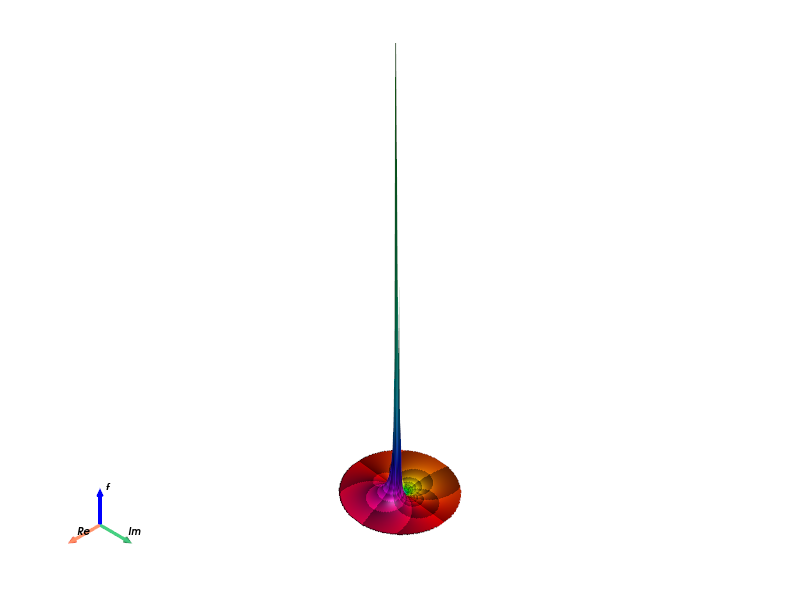


✓ Domain restriction prevents numerical issues near z=0


In [14]:
# Function with essential singularity at origin
def exp_inv_z(z):
    return np.exp(1/z)

# Restrict domain to avoid singularity
safe_domain = cp.Annulus(0.2, 3.0)  # Exclude origin

# Visualize with 3D
print("Visualizing essential singularity with domain restriction...")

cp.plot_landscape_pv(
    domain=safe_domain,
    func=exp_inv_z,
    cmap=cp.Phase(phase_sectors=12, auto_scale_r=True, v_base=0.3),
    resolution=120,
    z_scale=0.3
)

print("\n✓ Domain restriction prevents numerical issues near z=0")

## 5. STL Export for 3D Printing

Transform your visualizations into physical objects!

In [15]:
# Function suitable for 3D printing
print_func = lambda z: (z**3 - 1) / (z**3 + 1)

# Create ornament generator
ornament = OrnamentGenerator(
    func=print_func,
    resolution=400,  # Balance quality vs file size
    scaling='arctan',  # Good for bounded output
    scaling_params={'r_min': 0.4, 'r_max': 0.9},
    cmap=cp.Phase(phase_sectors=8, auto_scale_r=True)
)

# Generate the ornament
print("Generating STL file...")
output_file = 'complex_ornament.stl'
ornament.generate_and_save(
    filename=output_file,
    size_mm=60,
    verbose=True
)

print(f"\n✓ STL file saved: {output_file}")

Generating STL file...
Generating Riemann sphere ornament:
  Resolution: 400
  Scaling: arctan
  Parameters: {'r_min': 0.4, 'r_max': 0.9}
  Normalization: 1.00003 (geometric)
  Generated mesh: 160000 vertices, 159201 faces
  Radius range: [0.402, 0.896]

Repairing mesh...
=== Simple Mesh Repair ===
Input: 160000 points, 159201 faces
Cleaning mesh...


  After clean: 159600 points, 159201 faces
Filling holes...
Initial boundary edges: 798
After filling: 0 boundary edges
Reduced boundary edges by 798


Final: 159600 points, 159995 faces
[ok] Mesh is watertight


=== Mesh Validation Results ===
Watertight: True (0 boundary edges)
Manifold: True (0 non-manifold edges)
Dimensions: 56.257 x 60.000 x 50.010
Volume: 67917.117
Surface area: 8602.226
Radius from origin (at 60mm): 15.460 to 34.462, measured before centring
Ridge width between adjacent features is not measured; min radius is the proxy.

=== Overall Assessment ===
[ok] Mesh is ready for 3D printing!



Saved STL file: complex_ornament.stl
File size: 15.22 MB

✓ STL file saved: complex_ornament.stl


## 6. Publication-Quality Figures

Create figures suitable for papers and presentations.

In [16]:
# High-resolution figure with custom layout
fig = plt.figure(figsize=(12, 8), dpi=150)
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Main function display
ax_main = fig.add_subplot(gs[0:2, 0:2])
cp.plot(
    cp.Rectangle(3, 3),
    lambda z: (z**4 - 1) / (z**2 + 1),
    cmap=cp.Phase(phase_sectors=8, auto_scale_r=True, v_base=0.4),
    ax=ax_main,
    resolution=800  # High resolution
)
ax_main.set_title(r"$f(z) = \frac{z^4 - 1}{z^2 + 1}$", fontsize=16)

# Phase key
ax_key = fig.add_subplot(gs[0, 2])
cp.plot(
    cp.Disk(1),
    lambda z: z,
    cmap=cp.Phase(),
    ax=ax_key,
    resolution=800
)
ax_key.set_title("Phase Key", fontsize=12)
ax_key.set_xticks([])
ax_key.set_yticks([])

# Modulus plot
ax_mod = fig.add_subplot(gs[1, 2])
domain = cp.Rectangle(3, 3)
z = domain.mesh(500)
f_vals = (z**4 - 1) / (z**2 + 1)
mod = ax_mod.imshow(
    np.abs(f_vals), 
    extent=[-1.5, 1.5, -1.5, 1.5],
    cmap='viridis',
    origin='lower'
)
ax_mod.set_title("Modulus", fontsize=12)
ax_mod.set_xlabel("Re(z)")
ax_mod.set_ylabel("Im(z)")
plt.colorbar(mod, ax=ax_mod, fraction=0.046, pad=0.04)

# Save for publication
plt.savefig("publication_figure.png", dpi=300, bbox_inches='tight')
plt.savefig("publication_figure.pdf", bbox_inches='tight')  # Vector format
plt.show()

print("✓ Saved high-resolution PNG and PDF")

✓ Saved high-resolution PNG and PDF


C:\Users\igork\AppData\Local\Temp\ipykernel_14028\4265009561.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Summary

You've explored:
1. ✓ All colormap types and their applications
2. ✓ High-performance 3D with PyVista
3. ✓ Riemann sphere projections with modulus scaling
4. ✓ Riemann surfaces of multivalued functions
5. ✓ Domain composition for complex regions
6. ✓ STL export for 3D printing
7. ✓ Publication-quality figure creation

## Key Takeaways

- **PyVista** powers all 3D; in notebooks the **static backend** embeds plots inline
- **Domain restriction** helps with numerical stability
- **Auto-scaled phase portraits** create visually pleasing square cells
- **Different colormaps** reveal different function properties
- **STL export** transforms math into physical objects

## Next Steps

Check out `api_cookbook.ipynb` for common function patterns, the preset registry, and recipes.